In [4]:
import folium
import pandas as pd 
from scrapper.AlquilerScrapper import Scrapper
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast
from shapely.ops import unary_union


Lectura y limpieza de datos

1. se leen los datos y se transforman en geodataframe añadiendo finromación sobre el barrio en CABA
2. Se borran los datos pertenecientes a barrios con menos de 5 datos
3. Se añade información sobre la cantidad de ambientes, pasando strings a nueros
4. Se añade la columna de area por metro cuadrado "area_m2", transformando los datos de string a numericos. Se borran los datos sin información de area x metro cuadradp
5. Se añade la columna expensas transformando string a numerico. Si no hay información de expensas, se asume que el valor es 0.
6. Se borran los datos con precio de alquiler menor a 100000 pesos

In [5]:
df = pd.read_csv("storage/data/historic/arg_alquiler_data.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2324 entries, 0 to 2323
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                2324 non-null   int64  
 1   url               2324 non-null   object 
 2   precio            2324 non-null   object 
 3   expensas          2324 non-null   float64
 4   area_m2           2164 non-null   float64
 5   dormitorios       1699 non-null   object 
 6   antiguedad        2035 non-null   float64
 7   puntaje_arg_prop  2324 non-null   float64
 8   imagen_path       2315 non-null   object 
 9   image_url         2324 non-null   object 
 10  lat               2260 non-null   float64
 11  lon               2260 non-null   float64
 12  valido_desde      2324 non-null   object 
 13  valido_hasta      934 non-null    object 
dtypes: float64(6), int64(1), object(7)
memory usage: 254.3+ KB


Feature engeneering

In [6]:
df['id'].value_counts()[lambda x: x > 1]


Series([], Name: count, dtype: int64)

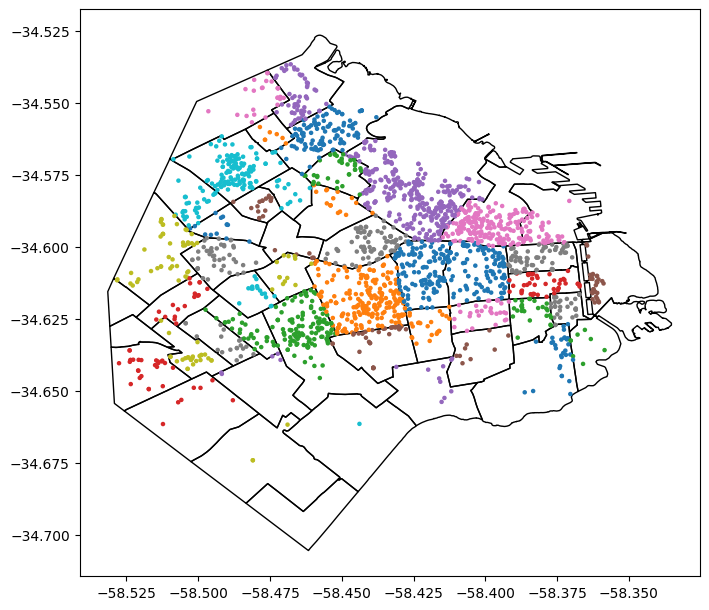

In [7]:


# Barrios
barrios = gpd.read_file("barrios.geojson")


caba_polygon = unary_union(barrios.geometry)


# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf_join = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)


gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf_join = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)
gdf_join = gdf_join.rename(columns={"nombre": "barrio"})

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf_join.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False
)

# Eliminamos barrios con menos de 5 observaciones
gdf_join = gdf_join[
    gdf_join.groupby('barrio')['barrio'].transform('size') >= 5
]


In [8]:
gdf_join['precio']

0        ('$', 430000.0)
1        ('$', 750000.0)
2       ('$', 1400000.0)
3        ('$', 780000.0)
4        ('$', 850000.0)
              ...       
2318     ('$', 700000.0)
2319      ('usd', 500.0)
2321     ('$', 600000.0)
2322     ('$', 550000.0)
2323     ('$', 600000.0)
Name: precio, Length: 2247, dtype: object

In [9]:
gdf_join['dormitorios'] = gdf_join['dormitorios'].fillna(0)
gdf_join['ambientes'] = gdf_join['dormitorios'].astype(str).str.extract('(\d+)').astype(int) + 1
gdf_join['ambientes']

print("cantidad de nulos en area_m2:", gdf_join['area_m2'].isna().sum())


mask = gdf_join['area_m2'].isna() & gdf_join['ambientes'].notna()

gdf_join.loc[mask, 'area_m2'] = (
    gdf_join.groupby('ambientes')['area_m2']
      .transform('median')
      .loc[mask]
)


gdf_join['expensas'] = pd.to_numeric(gdf_join['expensas'], errors='coerce')

print("cantidad de nulos en expensas:", gdf_join['expensas'].isna().sum())

gdf_join['expensas'].fillna(0, inplace=True)


gdf_join = gdf_join[~gdf_join['precio'].apply(lambda x: pd.isna(x[0]))]
valor_dolar_oficial_venta = pd.read_csv("storage/data/dolar_hoy.csv").iloc[0]['valor']



def parse_precio(x):
    if pd.isna(x):
        return (None, None)
    if isinstance(x, tuple):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return (None, None)
    return (None, None)


parsed = gdf_join['precio'].apply(parse_precio)

gdf_join['moneda'] = parsed.str[0]
gdf_join['precio'] = pd.to_numeric(parsed.str[1], errors='coerce')

gdf_join = gdf_join[~gdf_join['precio'].isna()]




gdf_join.head()


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en area_m2: 157
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
cantidad de nulos en expensas: 0
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,lat,lon,valido_desde,valido_hasta,geometry,index_right,barrio,comuna,ambientes,moneda
0,6688799,https://www.argenprop.com/departamento-en-alqu...,430000.0,70000.0,30.0,0,0.0,6446.0,images/6688799.jpg,https://www.argenprop.com/static-content/99788...,-34.56565,-58.44018,2026-01-27 19:05:20.636338,2026-02-01 19:09:59.362045,POINT (-58.44018 -34.56565),20.0,Palermo,14.0,1,$
1,18688308,https://www.argenprop.com/departamento-en-alqu...,750000.0,200000.0,36.0,1 dorm.,15.0,6238.0,images/18688308.jpg,https://www.argenprop.com/static-content/80388...,-34.58207,-58.41242,2026-01-27 19:05:20.636338,2026-02-01 19:10:04.156520,POINT (-58.41242 -34.58207),20.0,Palermo,14.0,2,$
2,18762433,https://www.argenprop.com/departamento-en-alqu...,1400000.0,250000.0,63.0,1 dorm.,5.0,4919.0,images/18762433.jpg,https://www.argenprop.com/static-content/33426...,-34.59364,-58.42518,2026-01-27 19:05:20.636338,2026-02-01 19:10:09.039909,POINT (-58.42518 -34.59364),20.0,Palermo,14.0,2,$
3,17407957,https://www.argenprop.com/departamento-en-alqu...,780000.0,210000.0,37.0,1 dorm.,14.0,4919.0,images/17407957.jpg,https://www.argenprop.com/static-content/75970...,-34.57914,-58.43462,2026-01-27 19:05:20.636338,2026-02-01 19:10:14.086720,POINT (-58.43462 -34.57914),20.0,Palermo,14.0,2,$
4,18583518,https://www.argenprop.com/departamento-en-alqu...,850000.0,270000.0,41.0,1 dorm.,56.0,4601.0,images/18583518.jpg,https://www.argenprop.com/static-content/81538...,-34.59462,-58.38720,2026-01-27 19:05:20.636338,2026-02-01 19:10:18.846140,POINT (-58.3872 -34.59462),28.0,Retiro,1.0,2,$


Elimino los precios muy bajos (menores a 8000 USD) y añado una columna con el precio por metro cuadrado

In [10]:
gdf_join = gdf_join.drop(gdf_join[gdf_join['precio'] <= 8000]['precio'].index)

EDA

Hipotesis: El precio depende de la superficie (en m^2) y de la cantidad de ambientes, pero esta relación es igual en todo el mapa?
Por ejemplo, podría ser que si comparamos un departamento con x m^2 y 3 ambientes y vemos cuanto cambia el precio al añadir 1 ambiente más, la diferencia d eprecio sea mayor en palermo que en caballito, por lo que existe una dependencia espacial en la relación subyacente (quizá en palermo no es tan importante tener muchos ambientes y en caballito si) 

Analisis: Graficar la dependencia entre precio en USD y superficie en m^2 para cada cantidad de ambientes en cada barrio
Si vemos que las pendientes de las curvas para cada cantidad de ambientes cambia en los distintos barrios, estamos evidenciando una dependencia espacial en la relación.


In [11]:
densidad_naive = (
    gdf_join
    .groupby('barrio')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


barrio
Palermo      216
Caballito    207
Recoleta     142
Almagro      125
Flores       114
dtype: int64

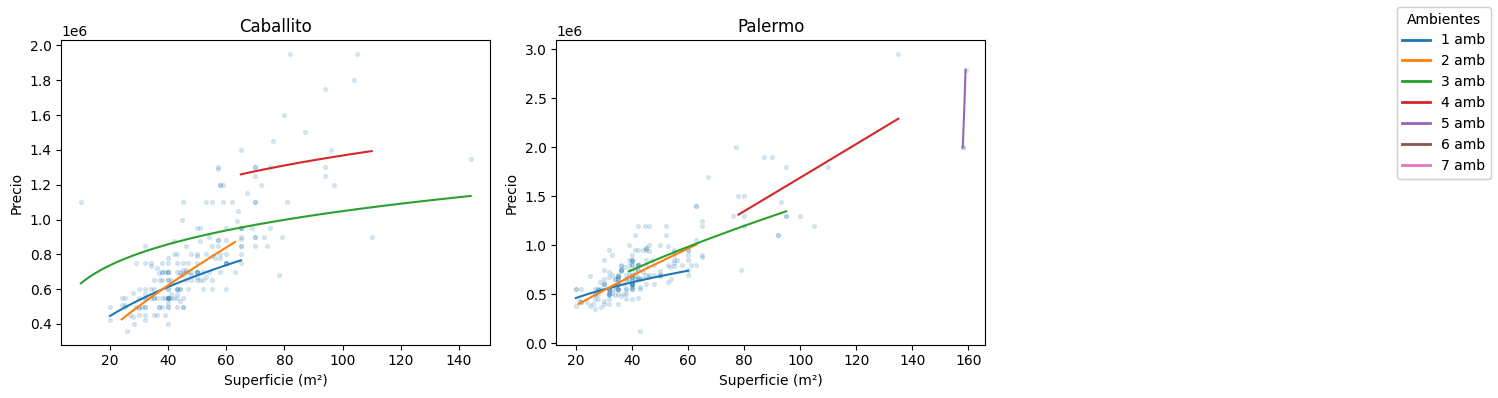

In [12]:
################## cambiar min obs ##################
min_obs = 150

barrios_con_observaciones = (
    gdf_join
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf_join['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf_join['area_m2'].min()
xmax = 400

ymin = gdf_join['precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf_join[gdf_join['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2'],
        gdf_b['precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(np.log(sub['area_m2']))
        y = np.log(sub['precio'])

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2'].min(),
            sub['area_m2'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(np.log(x_grid))
        )

        ax.plot(
            x_grid,
            np.exp(y_hat),
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# analisis de antiguedad


In [13]:
gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,lat,lon,valido_desde,valido_hasta,geometry,index_right,barrio,comuna,ambientes,moneda
11,18800435,https://www.argenprop.com/departamento-en-alqu...,600000.0,160000.0,40.00,1 dorm.,NaN,3654.0,images/18800435.jpg,https://www.argenprop.com/static-content/53400...,-34.57489,-58.44044,2026-01-27 19:05:20.636338,NaN,POINT (-58.44044 -34.57489),20.0,Palermo,14.0,2,$
35,17755546,https://www.argenprop.com/departamento-en-alqu...,800000.0,0.0,48.00,1 dorm.,NaN,2668.0,images/17755546.jpg,https://www.argenprop.com/static-content/64555...,-34.59539,-58.39548,2026-01-27 19:05:20.636338,NaN,POINT (-58.39548 -34.59539),27.0,Recoleta,2.0,2,$
45,18773142,https://www.argenprop.com/departamento-en-alqu...,500000.0,90000.0,20.00,0,NaN,2254.0,images/18773142.jpg,https://www.argenprop.com/static-content/24137...,-34.58883,-58.40360,2026-01-27 19:05:20.636338,NaN,POINT (-58.4036 -34.58883),27.0,Recoleta,2.0,1,$
60,4198585,https://www.argenprop.com/departamento-en-alqu...,820000.0,0.0,42.00,1 dorm.,NaN,2107.0,images/4198585.jpg,https://www.argenprop.com/static-content/58589...,-34.63130,-58.42564,2026-01-27 19:05:20.636338,NaN,POINT (-58.42564 -34.6313),6.0,Boedo,5.0,2,$
63,18771919,https://www.argenprop.com/departamento-en-alqu...,580000.0,130000.0,33.00,1 dorm.,NaN,2028.0,images/18771919.jpg,https://www.argenprop.com/static-content/91917...,-34.62154,-58.42628,2026-01-27 19:05:20.636338,2026-02-01 19:16:12.217880,POINT (-58.42628 -34.62154),1.0,Almagro,5.0,2,$
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2297,18952871,https://www.argenprop.com/departamento-en-alqu...,600000.0,125000.0,30.00,1 dorm.,NaN,1.0,images/18952871.jpg,https://www.argenprop.com/static-content/17825...,-34.59777,-58.41880,2026-02-01 19:09:53.096940,NaN,POINT (-58.4188 -34.59777),20.0,Palermo,14.0,2,$
2299,18938197,https://www.argenprop.com/departamento-en-alqu...,520000.0,147000.0,35.00,0,NaN,0.0,images/18938197.jpg,https://www.argenprop.com/static-content/79183...,-34.61166,-58.41412,2026-02-01 19:09:53.106629,NaN,POINT (-58.41412 -34.61166),1.0,Almagro,5.0,1,$
2300,18938237,https://www.argenprop.com/departamento-en-alqu...,780000.0,279300.0,53.63,2 dorm.,NaN,0.0,images/18938237.jpg,https://www.argenprop.com/static-content/73283...,-34.57308,-58.44147,2026-02-01 19:09:53.112870,NaN,POINT (-58.44147 -34.57308),20.0,Palermo,14.0,3,$
2310,18950099,https://www.argenprop.com/departamento-en-alqu...,400000.0,77000.0,30.00,0,NaN,1.0,images/18950099.jpg,https://www.argenprop.com/static-content/99005...,-34.62017,-58.40917,2026-02-01 19:09:53.138766,NaN,POINT (-58.40917 -34.62017),30.0,San Cristobal,3.0,1,usd


Extraigo datos antiguedad, relleno con la media del barrio cuando no esta precenta (a muchos a estrenar le estoy poniendo mal el dato, se tiene que corregir.)

In [14]:

gdf_join['antiguedad'] = (
    gdf_join['antiguedad']
    .fillna(
        gdf_join
        .groupby('barrio')['antiguedad']
        .transform('mean')
    )
)

gdf_join[gdf_join['antiguedad'].isna()]

,id,url,precio,expensas,area_m2,dormitorios,antiguedad,puntaje_arg_prop,imagen_path,image_url,lat,lon,valido_desde,valido_hasta,geometry,index_right,barrio,comuna,ambientes,moneda


Variograma por precio

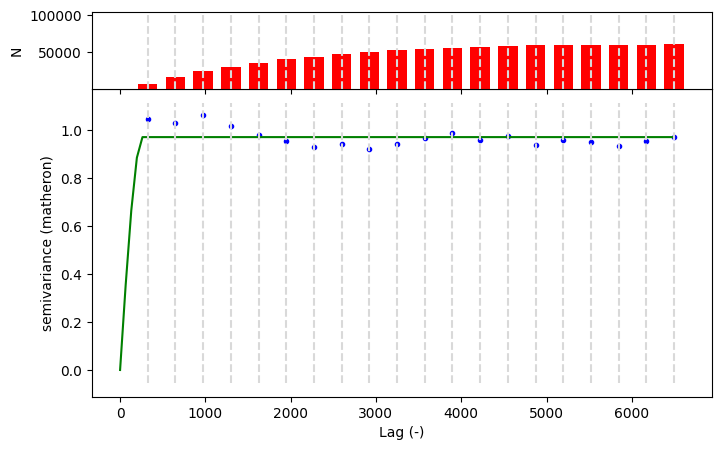

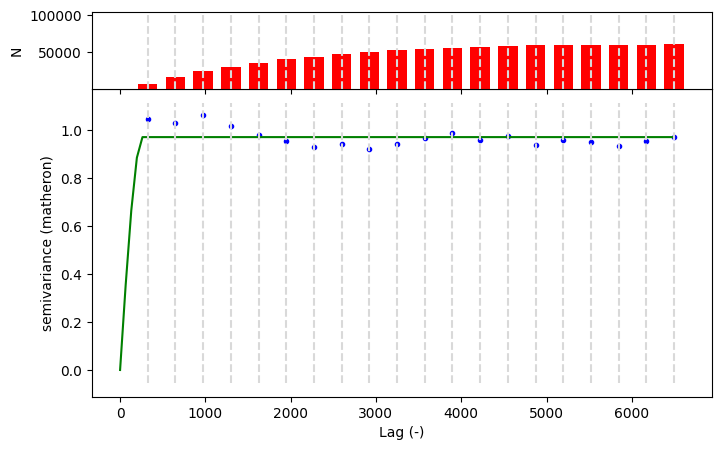

In [15]:


gdf = gdf_join.to_crs(epsg=3857)
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

values = gdf['precio'].values

V = Variogram(
    coords,
    values,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=20,
    maxlag='median',     # o una distancia en metros
    normalize=False
)
V.plot()

# Formulamos y entrenamos modelo

hacemos GWR + kriging en residuos. 

Lueog hacemos un RF + Krigin en residuos

In [16]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from esda.moran import Moran_Local
from libpysal.weights import KNN
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from patsy import dmatrices
from sklearn.preprocessing import StandardScaler
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
from pykrige.rk import RegressionKriging
from xgboost import XGBRegressor
from statsmodels.robust.scale import mad
from libpysal.weights import Kernel


In [17]:
gdf.columns

Index(['id', 'url', 'precio', 'expensas', 'area_m2', 'dormitorios',
       'antiguedad', 'puntaje_arg_prop', 'imagen_path', 'image_url', 'lat',
       'lon', 'valido_desde', 'valido_hasta', 'geometry', 'index_right',
       'barrio', 'comuna', 'ambientes', 'moneda'],
      dtype='object')

In [18]:
class SpatialKernelPriceModel:
    def __init__(self, gdf: gpd.GeoDataFrame, use_log: bool = True):
        self._check_data_validity(gdf)

        self.data = gdf
        self.use_log_ = use_log

        self.bw_ = None
        self.results_ = None
        self.scaler_ = None
        self.gwr_ = None

        self.coords_train_ = None
        self.y_train_ = None
        self.X_train_ = None
        self.response_var_ = None

    # ----------------------------
    # Validaciones
    # ----------------------------
    def _check_data_validity(self, data):
        if not isinstance(data, gpd.GeoDataFrame):
            raise TypeError("Input data must be a GeoDataFrame")

        if data.crs is None:
            raise ValueError("GeoDataFrame must have a CRS defined")

        if data.crs.to_epsg() != 3857:
            raise ValueError(
                f"GeoDataFrame CRS must be EPSG:3857, got {data.crs}"
            )

        if not set(data.geometry.geom_type).issubset({"Point"}):
            raise ValueError("Geometry must be Point for spatial kernel models")

    # ----------------------------
    # Transformaciones
    # ----------------------------
    def _transform_y(self, y):
        if self.use_log_:
            if np.any(y <= 0):
                raise ValueError("Log-transform requires strictly positive response variable")
            return np.log(y)
        return y

    def _inverse_transform_y(self, y):
        if self.use_log_:
            return np.exp(y)
        return y

    # ----------------------------
    # Fit
    # ----------------------------
    def fit(
        self,
        data: gpd.GeoDataFrame,
        features_vars: list[str],
        response_var: str = "precio"
    ):
        self._check_data_validity(data)
        self.data = data
        self.response_var_ = response_var

        # Coordenadas
        coords = np.column_stack([
            data.geometry.x,
            data.geometry.y
        ])

        # Variable respuesta
        y_raw = data[response_var].values.reshape(-1, 1)
        y = self._transform_y(y_raw)

        # Covariables
        X = data[features_vars].values

        # Guardar train
        self.coords_train_ = coords
        self.y_train_ = y
        self.X_train_ = X

        # Normalización
        self.scaler_ = StandardScaler()
        X_std = self.scaler_.fit_transform(X)

        # Bandwidth
        bw_selector = Sel_BW(
            coords,
            y,
            X_std,
            spherical=False
        )
        self.bw_ = bw_selector.search()

        # GWR
        self.gwr_ = GWR(
            coords,
            y,
            X_std,
            bw=self.bw_,
            fixed=False,
            kernel="bisquare"
        )

        self.results_ = self.gwr_.fit()

        return self

    # ----------------------------
    # Predict
    # ----------------------------
    def predict(self, gdf_new: gpd.GeoDataFrame, features_vars: list[str]):
        if self.gwr_ is None:
            raise RuntimeError("Model is not fitted yet")

        self._check_data_validity(gdf_new)

        coords_new = np.column_stack([
            gdf_new.geometry.x,
            gdf_new.geometry.y
        ])

        X_new = gdf_new[features_vars].values
        X_new_std = self.scaler_.transform(X_new)

        gwr_pred = GWR(
            self.coords_train_,
            self.y_train_,
            self.X_train_,
            bw=self.bw_,
            kernel="bisquare",
            fixed=False,
            n_jobs=1
        )

        preds_internal = gwr_pred.predict(
            coords_new,
            X_new_std
        ).predictions.flatten()

        # Volver a escala original
        return self._inverse_transform_y(preds_internal)

    # ----------------------------
    # Summary
    # ----------------------------
    def summary(self):
        if self.results_ is None:
            raise RuntimeError("Model is not fitted yet")

        print(self.results_.summary())
        return self.results_.summary()

    def results(self):
        if self.results_ is None:
            raise RuntimeError("Model is not fitted yet")
        return self.results_


In [19]:
gdf = gdf.to_crs(epsg=3857)

gdf_train, gdf_test = train_test_split(
    gdf,
    test_size=0.2,
    random_state=42
)

In [20]:

model = SpatialKernelPriceModel(gdf)

model.fit(
    data=gdf_train,
    features_vars=[
        'area_m2',
        'ambientes',
        'antiguedad',
        'expensas'
    ],
    response_var='precio',
)


In [21]:
model.summary()

Model type                                                         Gaussian
Number of observations:                                                1542
Number of covariates:                                                     5

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            100.203
Log-likelihood:                                                     -80.370
AIC:                                                                170.740
AICc:                                                               172.795
BIC:                                                             -11182.661
R2:                                                                   0.525
Adj. R2:                                                              0.524

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [22]:
y_test_pred = model.predict(
        gdf_test,
        features_vars=[
            'area_m2',
            'ambientes',
            'antiguedad',
            'expensas'
        ]
)

y_test_true = gdf_test['precio'].values
rmse_price = np.sqrt(mean_squared_error(
    y_test_true,
    y_test_pred
))



rmse = np.sqrt(mean_squared_error(
    gdf_test['precio'].values,
    y_test_pred
))

mae = mean_absolute_error(
    gdf_test['precio'].values,
    y_test_pred
)

adj_R2 = model.results().adj_R2

rmse, mae, adj_R2


(493148.6561194061, 384020.0974108503, 0.629407751344071)

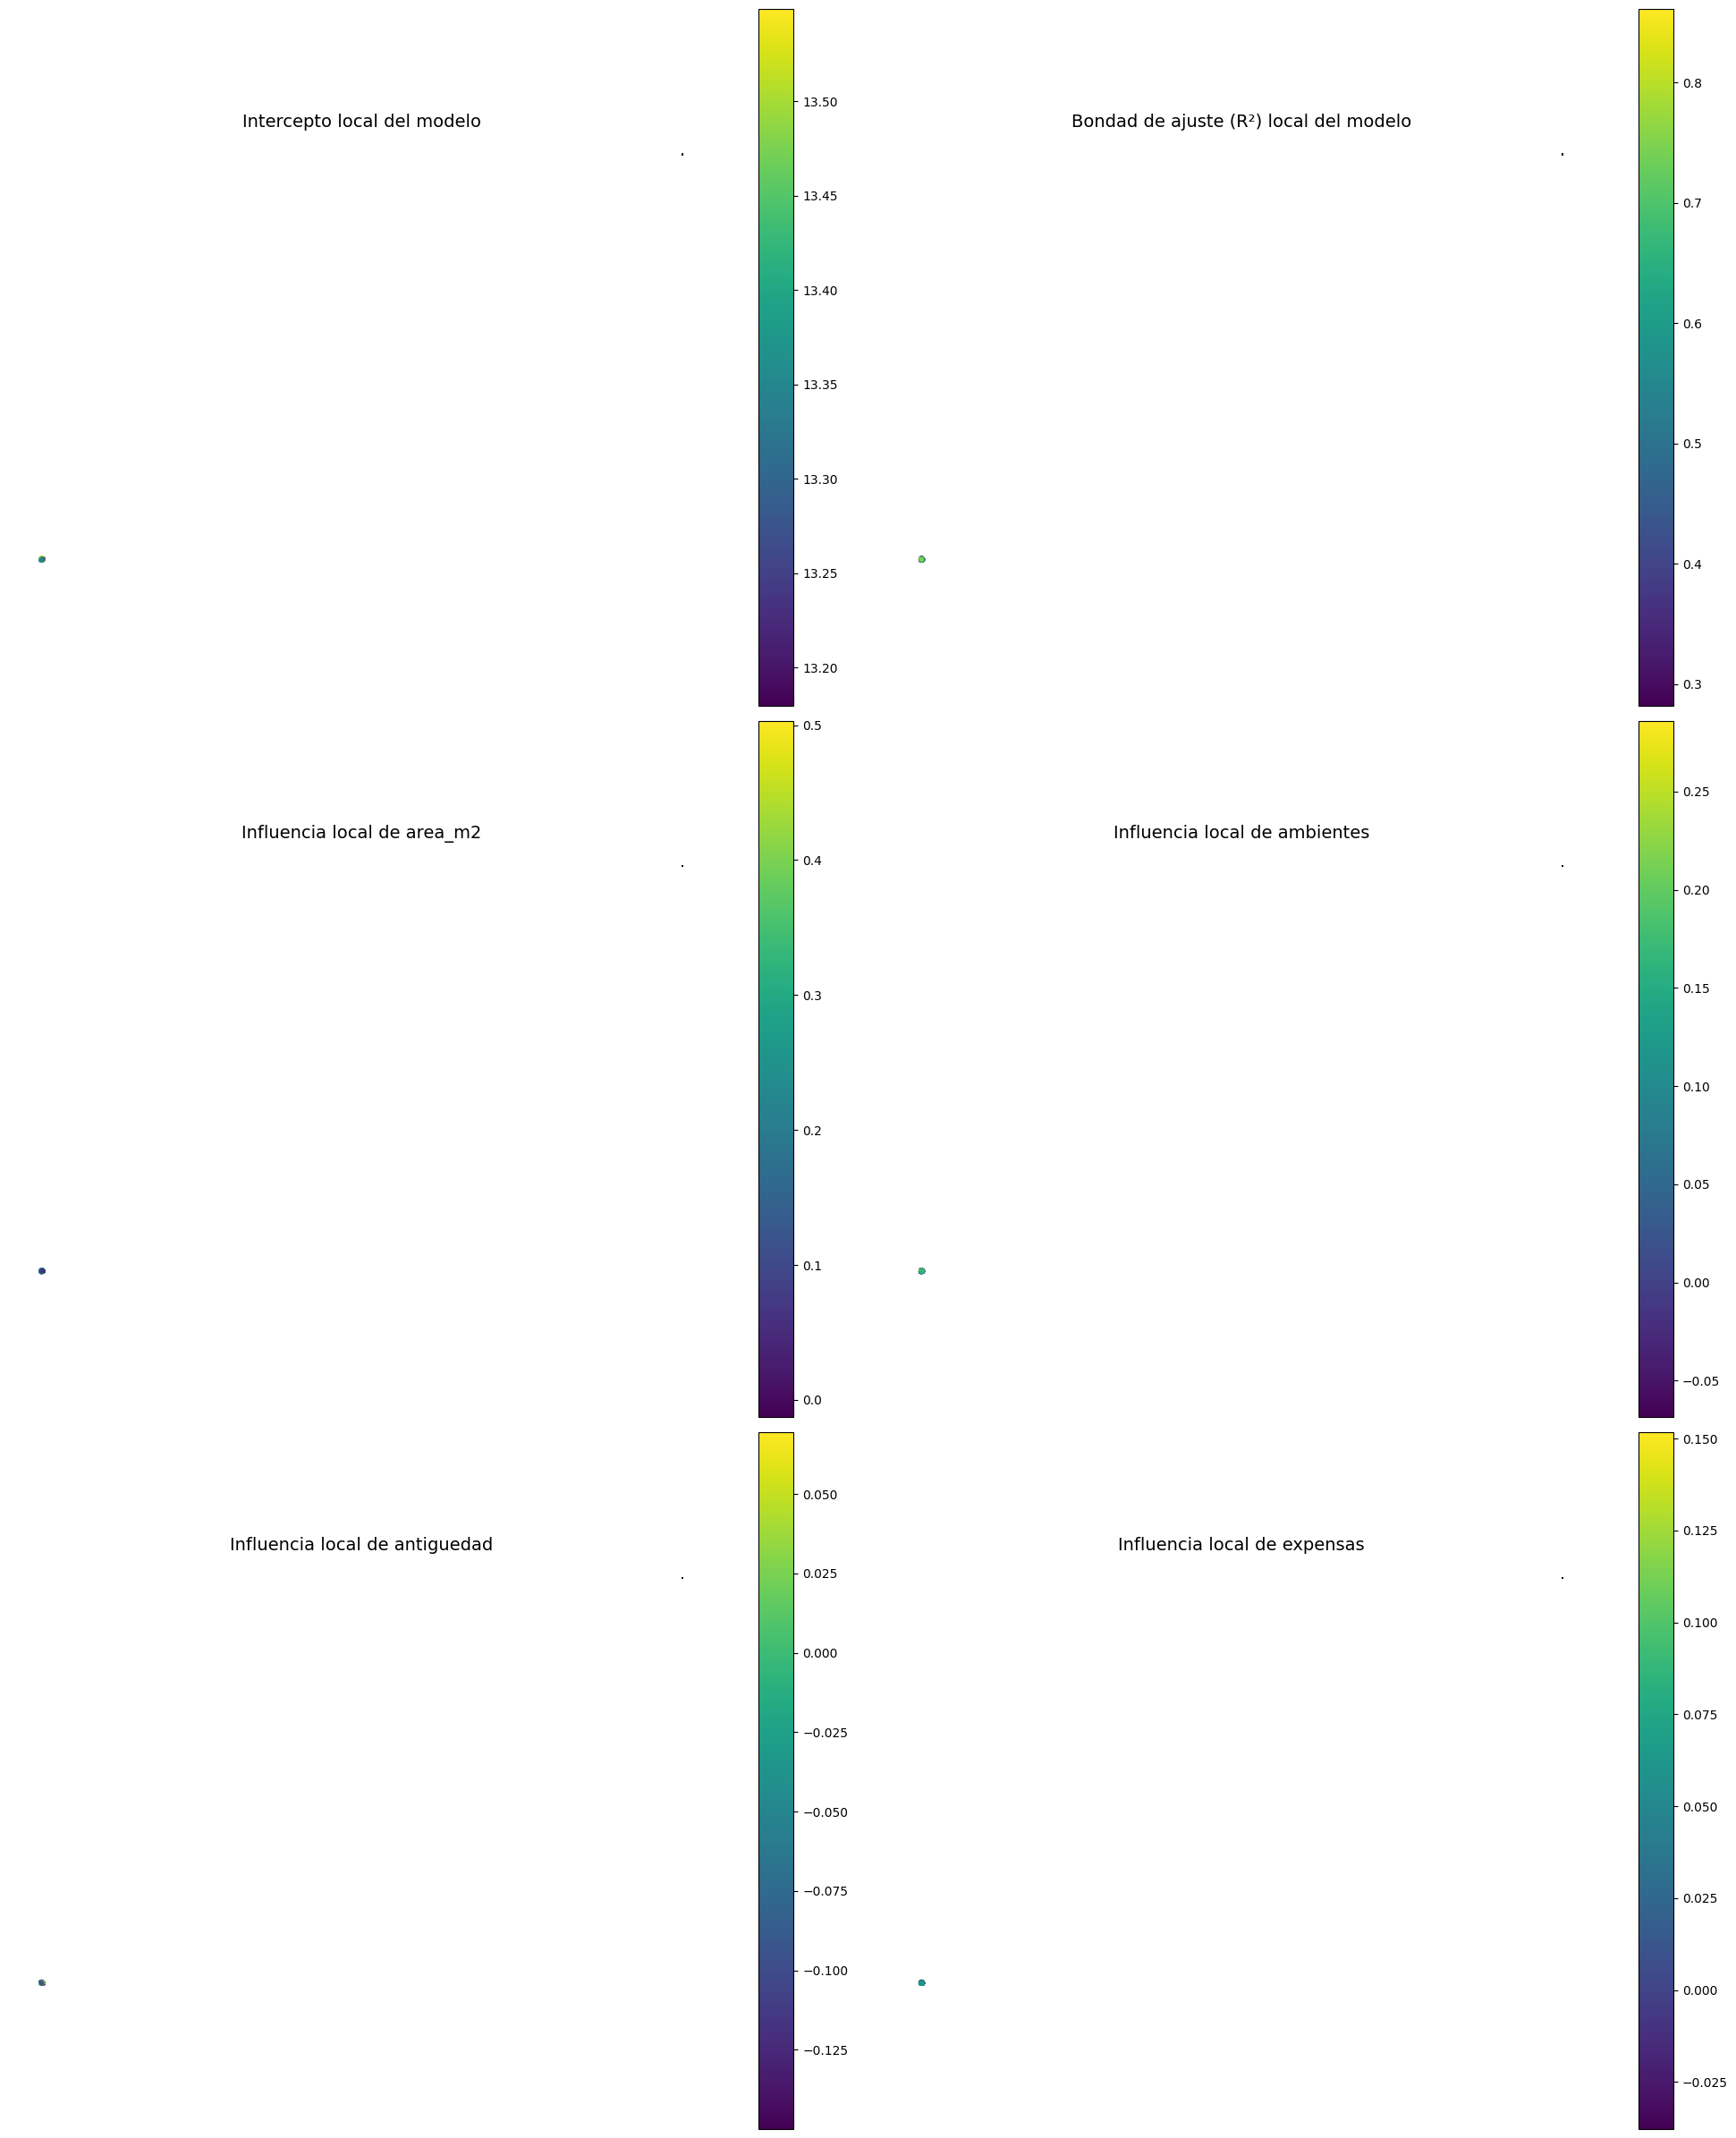

In [23]:
var_names = [
            'area_m2',
            'ambientes',
            'antiguedad',
            'expensas'
        ]
res = model.results()

coefs = pd.DataFrame(
    res.params[:, 1:],   # coeficientes (sin intercepto)
    columns=var_names,
    index=gdf_train.index
)

# coeficientes
for v in var_names:
    gdf_train[f'beta_{v}'] = coefs[v]

# intercepto local
gdf_train["intercept"] = res.params[:, 0]

# R² local
gdf_train["local_R2"] = res.localR2


coef_names = [
     "intercept", "local_R2",
     "beta_area_m2", "beta_ambientes",
     "beta_antiguedad", "beta_expensas"
]

fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten()


for ax, coef in zip(axes, coef_names):

    # ---- fondo: barrios ----
    barrios.plot(
        ax=ax,
        edgecolor="black",
        facecolor="lightgrey",
        alpha=0.6
    )

    # ---- puntos: resultados GWR ----
    gdf_train.plot(
        ax=ax,
        column=coef,
        legend=True,
        markersize=8,
        alpha=0.85
    )

    # ---- títulos más claros ----
    if coef.startswith("beta_"):
        title = f"Influencia local de {coef.replace('beta_', '')}"
    elif coef == "intercept":
        title = "Intercepto local del modelo"
    elif coef == "local_R2":
        title = "Bondad de ajuste (R²) local del modelo"

    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()


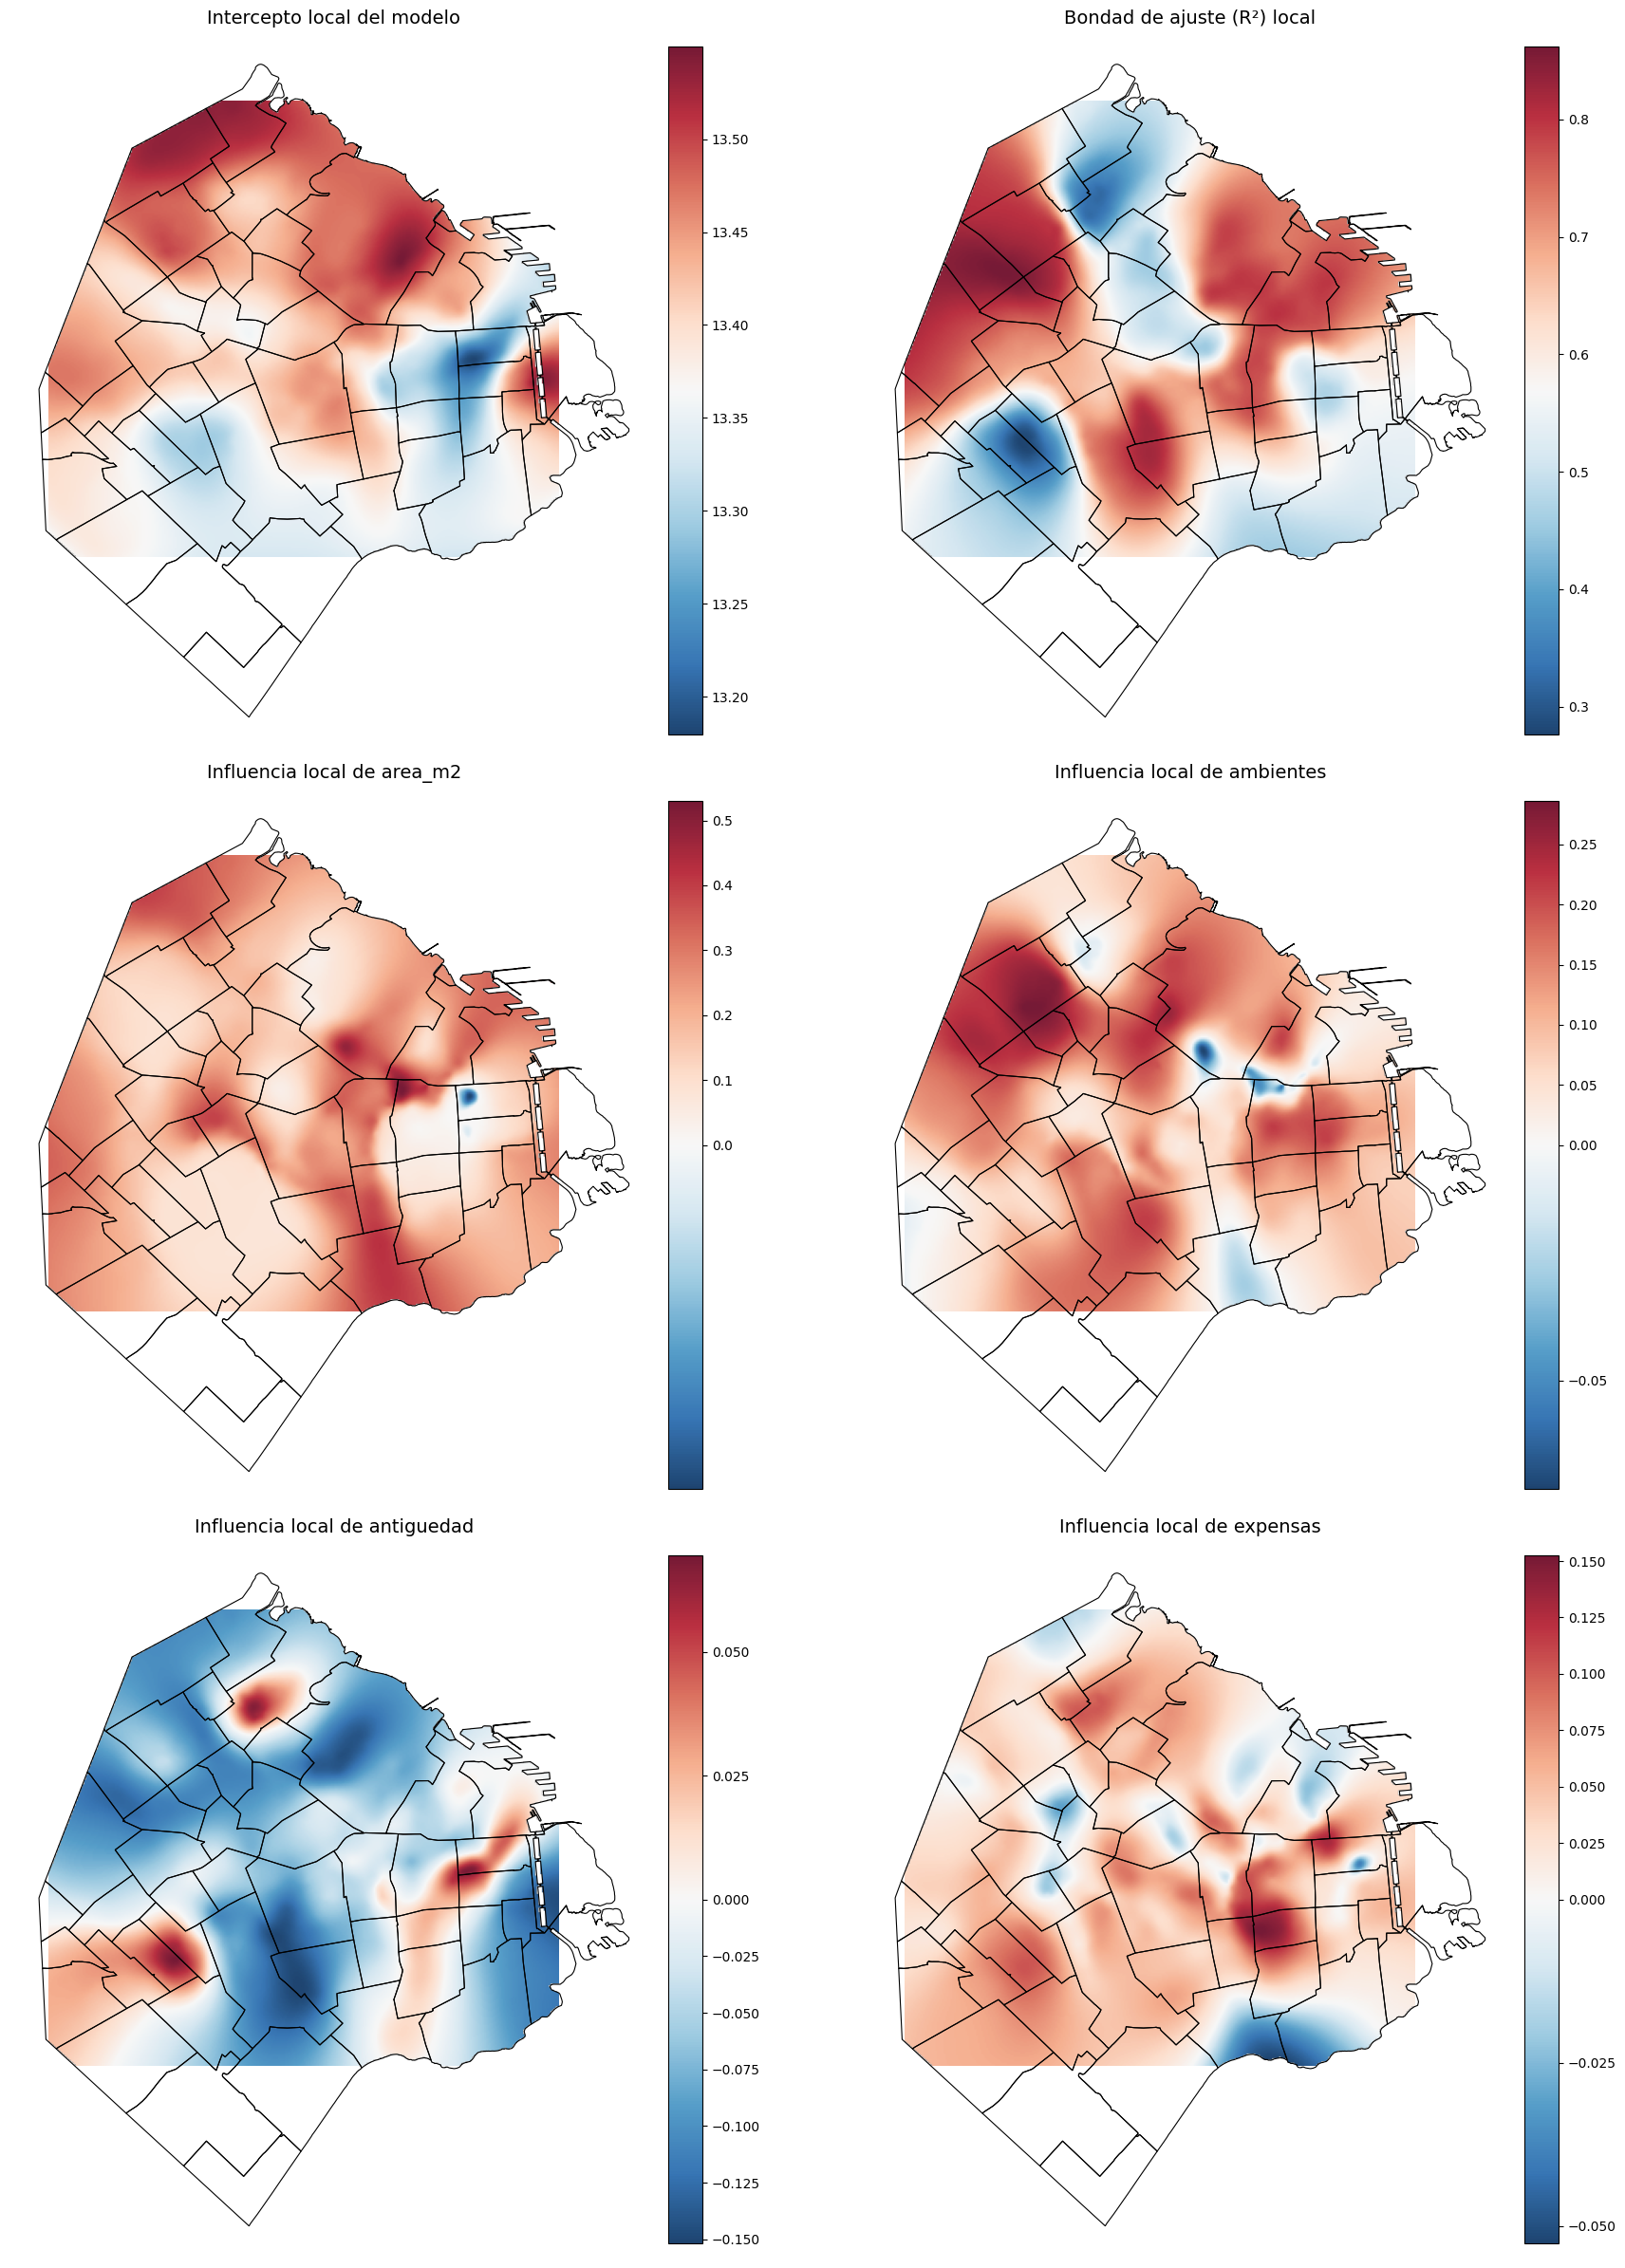

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from scipy.interpolate import Rbf

barrios = barrios.to_crs(gdf_train.crs)
caba_polygon = unary_union(barrios.geometry)


var_names = [
    'area_m2',
    'ambientes',
    'antiguedad',
    'expensas'
]

res = model.results()

coefs = pd.DataFrame(
    res.params[:, 1:],   # sin intercepto
    columns=var_names,
    index=gdf_train.index
)

for v in var_names:
    gdf_train[f'beta_{v}'] = coefs[v]

gdf_train["intercept"] = res.params[:, 0]
gdf_train["local_R2"] = res.localR2

x = gdf_train.geometry.x.values
y = gdf_train.geometry.y.values

grid_size = 300  # podés subir/bajar resolución
xi = np.linspace(x.min(), x.max(), grid_size)
yi = np.linspace(y.min(), y.max(), grid_size)
Xi, Yi = np.meshgrid(xi, yi)

extent = (x.min(), x.max(), y.min(), y.max())

mask = np.array([
    caba_polygon.contains(Point(x, y))
    for x, y in zip(Xi.ravel(), Yi.ravel())
]).reshape(Xi.shape)

def rbf_surface(x, y, z, Xi, Yi):
    rbf = Rbf(x, y, z, 
              function="thin_plate",
            smooth=1.0   
)
    Zi = rbf(Xi, Yi)
    return Zi

coef_names = [
    "intercept", "local_R2",
    "beta_area_m2", "beta_ambientes",
    "beta_antiguedad", "beta_expensas"
]

fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten()

for ax, coef in zip(axes, coef_names):

    # ---- raster suave ----
    Zi = rbf_surface(
        x,
        y,
        gdf_train[coef].values,
        Xi,
        Yi
    )
    
    zi_masked = np.where(mask, Zi, np.nan)

    zvals = zi_masked[np.isfinite(zi_masked)]

    if zvals.min() < 0 < zvals.max():
        norm = TwoSlopeNorm(
            vmin=zvals.min(),
            vcenter=0.0,
            vmax=zvals.max()
        )
    else:
        norm = None   # fallback automático

    im = ax.imshow(
        zi_masked,
        extent=extent,
        origin="lower",
        cmap="RdBu_r",
        norm=norm,
        alpha=0.9
    )

    # ---- contorno barrios ----
    barrios.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8
    )

    # ---- colorbar ----
    plt.colorbar(im, ax=ax, fraction=0.036, pad=0.01)

    # ---- títulos ----
    if coef.startswith("beta_"):
        title = f"Influencia local de {coef.replace('beta_', '')}"
    elif coef == "intercept":
        title = "Intercepto local del modelo"
    elif coef == "local_R2":
        title = "Bondad de ajuste (R²) local"

    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()



In [25]:
import numpy as np

def weighted_median(x, w):
    x = np.asarray(x)
    w = np.asarray(w)

    mask = (w > 0) & np.isfinite(x)
    x = x[mask]
    w = w[mask]

    if len(x) == 0:
        return np.nan

    idx = np.argsort(x)
    x_sorted = x[idx]
    w_sorted = w[idx]

    cum_w = np.cumsum(w_sorted)
    cutoff = 0.5 * np.sum(w_sorted)

    return x_sorted[np.searchsorted(cum_w, cutoff)]

def weighted_mad(x, w, normalize=True):
    x = np.asarray(x)
    w = np.asarray(w)

    mask = (w > 0) & np.isfinite(x)
    x = x[mask]
    w = w[mask]

    if len(x) == 0:
        return np.nan

    med = weighted_median(x, w)
    mad = weighted_median(np.abs(x - med), w)

    if normalize:
        return 1.4826 * mad
    else:
        return mad


In [26]:


coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])



w = Kernel(
    coords,
    k=8,                 # adaptive bandwidth
    function="gaussian",  # o "gaussian"
    fixed=False           # ← CLAVE: adaptativo
)


y_true = gdf['precio'].values

model_global = SpatialKernelPriceModel(gdf)

model_global.fit(
    data=gdf,
    features_vars=[
        'area_m2',
        'ambientes',
        'antiguedad',
        'expensas'
    ],
    response_var='precio'
)

y_pred = model_global.predict(
    gdf,
    features_vars=[
        'area_m2',
        'ambientes',
        'antiguedad',
        'expensas'
    ]
)
residuals = y_true - y_pred
res = residuals.copy()
lisa = Moran_Local(res, w)


outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))
gdf[outliers]
gdf[outliers].to_csv("output/alquiler/outliers_lisa_GWR.csv", index=False)

res_loc_std = np.zeros_like(res)

for i in range(len(res)):
    neighs = w.neighbors[i]
    local_vals = res[neighs]

    med = weighted_median(local_vals, w.weights[i])
    sigma = weighted_mad(local_vals, w.weights[i])  # robust scale

    res_loc_std[i] = (res[i] - med) / sigma if sigma > 0 else 0
outliers_2 = (
    (res_loc_std < np.percentile(res_loc_std, 5)) 
)

gdf[outliers_2]
gdf[outliers_2].to_csv("output/alquiler/outliers_lisa_GWR_ztest.csv", index=False)

In [27]:

outliers_3 = (
    (res_loc_std < np.percentile(res_loc_std, 5)) & (lisa.p_sim < 0.05)
)

gdf[outliers_3]
gdf[outliers_3].to_csv("output/alquiler/outliers_lisa_GWR_ztest_y_lisa.csv", index=False)

Según el siguiente varigorama, parece ser que el módelo quizá no esta capturando toda la variación espacial de los datos ya que el variograma marca que sigue existiendo una dependencia espacial en los residuos.

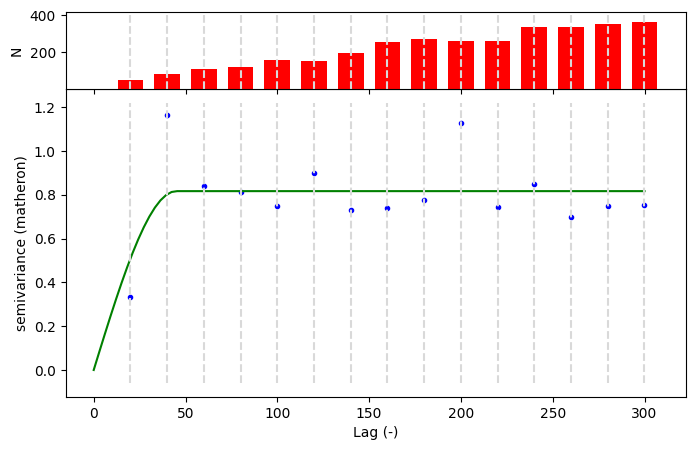

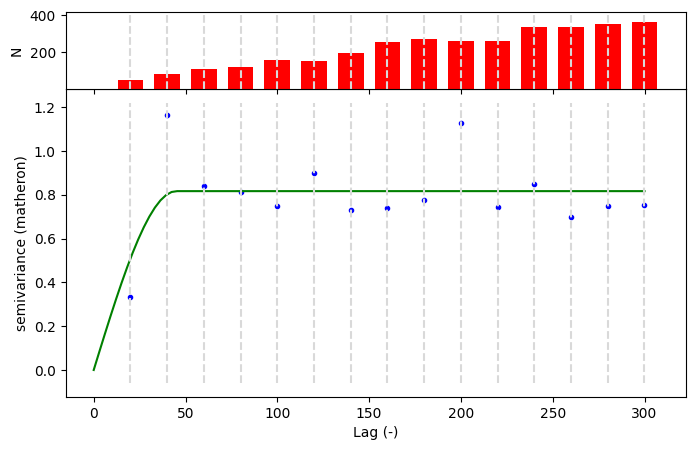

In [28]:

coords = np.column_stack([
    gdf_train.geometry.x,
    gdf_train.geometry.y
])

y_train_true = gdf_train['precio'].values
y_train_pred = model.predict(
        gdf_train,
        features_vars=[
            'area_m2',
            'ambientes',
            'antiguedad',
            'expensas'
        ]
)
residuals = y_train_true - y_train_pred

V = Variogram(
    coords,
    residuals,
    model='spherical',   # o 'exponential', 'gaussian'
    n_lags=15,
    maxlag=300,     # o una distancia en metros
    normalize=False
)
V.plot()

Random Forest + regression kriging

In [29]:

gdf_ml = gdf.copy()

gdf_ml['lon'] = gdf_ml.geometry.x
gdf_ml['lat'] = gdf_ml.geometry.y


features = [
    'lat', 'lon',
    'area_m2',
    'ambientes',
    'antiguedad',
    'expensas'
]

target = 'precio'

df = gdf_ml[features + [target]].copy()

# eliminar filas con target faltante
df = df.dropna(subset=[target])

X = df[features]
y = df[target]

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

coords = np.column_stack([
    gdf_ml.geometry.x.values,
    gdf_ml.geometry.y.values
])


X_train, X_test, y_train, y_test, coords_train, coords_test = train_test_split(
    X, y, coords, test_size=0.2, random_state=42
)

In [30]:

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kr_rf = RegressionKriging(
    rf,
    n_closest_points=10,
)

kr_rf.fit(X_train, coords_train, y_train)
rf.fit(X_train, y_train)


Finished learning regression model
Finished kriging residuals


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [31]:

y_pred_kr_rf = kr_rf.predict(X_test, coords_test)
y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("KR-RF R2:", r2_score(y_test, y_pred_kr_rf))
print("KR-RF MAE:", mean_absolute_error(y_test, y_pred_kr_rf))

pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)


RF R2: 0.7467161175374085
RF MAE: 114250.38823340737
KR-RF R2: 0.7577649799501245
KR-RF MAE: 110520.4526453703


area_m2       0.342490
ambientes     0.202422
expensas      0.185137
lat           0.101909
lon           0.087979
antiguedad    0.080064
dtype: float64

In [32]:


coords = np.column_stack([
    gdf_ml.geometry.x,
    gdf_ml.geometry.y
])


w = Kernel(
    coords,
    k=15,                 # adaptive bandwidth
    function="gaussian",  # o "gaussian"
    fixed=False           # ← CLAVE: adaptativo
)


y_true = gdf_ml['precio'].values

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

kr_rf = RegressionKriging(
    rf,
    n_closest_points=15,
)

kr_rf.fit(X_imp, coords, y_true)

y_pred_kr_rf = kr_rf.predict(X_imp, coords)
y_pred_rf = rf.predict(X_imp)

residuals = y_true - y_pred_kr_rf
res = residuals.copy()

lisa = Moran_Local(res, w)  

outliers = (
    (lisa.q == 3)    # Low-High
& (lisa.p_sim < 0.05))
gdf_ml[outliers]
gdf_ml[outliers].to_csv("output/alquiler/outliers_random_forest_regression_krigin.csv", index=False)


res_loc_std = np.zeros_like(res)

for i in range(len(res)):
    neighs = w.neighbors[i]
    local_vals = res[neighs]

    med = weighted_median(local_vals, w.weights[i])
    sigma = weighted_mad(local_vals, w.weights[i])  # robust scale

    res_loc_std[i] = (res[i] - med) / sigma if sigma > 0 else 0


outliers_2 = (
    (res_loc_std < np.percentile(res_loc_std, 5)) 
)

gdf_ml[outliers_2]
gdf_ml[outliers_2].to_csv("output/alquiler/outliers_random_forest_regression_krigin_ztest.csv", index=False)

Finished learning regression model
Finished kriging residuals
